# Task B-2: Model Training Implementation  
# Task B-3: Model Fairness Analysis

**Project:** Torterm — AI Home Renovation Chatbot  
**Task:** Train a product category classifier using TF-IDF + scikit-learn  
**Goal:** Given a product name + description, predict which of the 5 categories it belongs to

In [1]:
import json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Prepare Data

In [2]:
DATA_DIR = '../data'
files = ['homepro_exterior.json','con.json','dow.json','flo.json','out.json','pai.json']

records = []
for f in files:
    with open(os.path.join(DATA_DIR, f), encoding='utf-8') as fp:
        records.extend(json.load(fp))

df = pd.DataFrame(records)

cat_map = {
    'ประตูและหน้าต่าง': 'Door_Window',
    'วัสดุปูพื้นและผนัง': 'Floor_Wall',
    'วัสดุก่อสร้าง': 'Construction',
    'เฟอร์นิเจอร์นอกบ้านและสวน': 'Outdoor_Furniture',
    'สีและอุปกรณ์ทาสี': 'Paint_Tools'
}
df['label'] = df['category'].map(cat_map)

# Combine name + description as input text
df['text'] = df['name'].fillna('') + ' ' + df['description'].fillna('')

print(f'Dataset size: {len(df)}')
print('\nClass distribution:')
print(df['label'].value_counts())

Dataset size: 100

Class distribution:
label
Door_Window          20
Floor_Wall           20
Construction         20
Outdoor_Furniture    20
Paint_Tools          20
Name: count, dtype: int64


## 2. Preprocessing

In [3]:
import re

def preprocess(text):
    """Basic cleaning: remove URLs, excessive whitespace, special chars."""
    text = re.sub(r'https?://\S+', '', text)  # remove URLs
    text = re.sub(r'\s+', ' ', text)           # collapse whitespace
    text = text.strip()
    return text

df['text_clean'] = df['text'].apply(preprocess)

print('Sample cleaned text (first 200 chars):')
print(df['text_clean'].iloc[0][:200])
print(f'\nAvg text length: {df["text_clean"].str.len().mean():.0f} chars')

Sample cleaned text (first 200 chars):
ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หนา 2 นิ้ว 60x5x120 ซม. (แพ็ก 4 ชิ้น) ฉนวนกันเสียง ROCKWOOL SAFE N SILENT PRO 330 หนา 2 นิ้ว 60x5x120 ซม. (แพ็ก 4 ชิ้น) ป้องกันเสียงรบกวนทั้งจากภายนอกเข้าสู

Avg text length: 1470 chars


## 3. Train / Test Split

In [4]:
X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print('\nTrain class distribution:')
print(y_train.value_counts())
print('\nTest class distribution:')
print(y_test.value_counts())

Train size: 80 | Test size: 20

Train class distribution:
label
Paint_Tools          16
Outdoor_Furniture    16
Floor_Wall           16
Door_Window          16
Construction         16
Name: count, dtype: int64

Test class distribution:
label
Floor_Wall           4
Construction         4
Outdoor_Furniture    4
Door_Window          4
Paint_Tools          4
Name: count, dtype: int64


## 4. Model Architecture: TF-IDF + Logistic Regression

In [5]:
# TF-IDF with character n-grams — works well for Thai without word tokenization
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',   # character n-grams
        ngram_range=(2, 4),   # bigrams to 4-grams
        max_features=10000,
        sublinear_tf=True     # apply log(tf+1) scaling
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
       
    ))
])

print('Pipeline:')
print(pipeline)

Pipeline:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_range=(2, 4), sublinear_tf=True)),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


## 5. Training with Stratified K-Fold Cross-Validation

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')

print('=== 5-Fold Cross-Validation (F1 Macro) ===')
for i, score in enumerate(cv_scores):
    print(f'  Fold {i+1}: {score:.4f}')
print(f'  Mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

=== 5-Fold Cross-Validation (F1 Macro) ===
  Fold 1: 1.0000
  Fold 2: 0.9314
  Fold 3: 0.8743
  Fold 4: 0.8814
  Fold 5: 0.8248
  Mean:   0.9024 ± 0.0594


## 6. Train Final Model and Evaluate

In [7]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f'Test Accuracy: {acc:.4f}')
print(f'Test F1 Macro: {f1:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9000
Test F1 Macro: 0.9029

=== Classification Report ===
                   precision    recall  f1-score   support

     Construction       1.00      0.75      0.86         4
      Door_Window       1.00      0.75      0.86         4
       Floor_Wall       0.67      1.00      0.80         4
Outdoor_Furniture       1.00      1.00      1.00         4
      Paint_Tools       1.00      1.00      1.00         4

         accuracy                           0.90        20
        macro avg       0.93      0.90      0.90        20
     weighted avg       0.93      0.90      0.90        20



## 7. Confusion Matrix

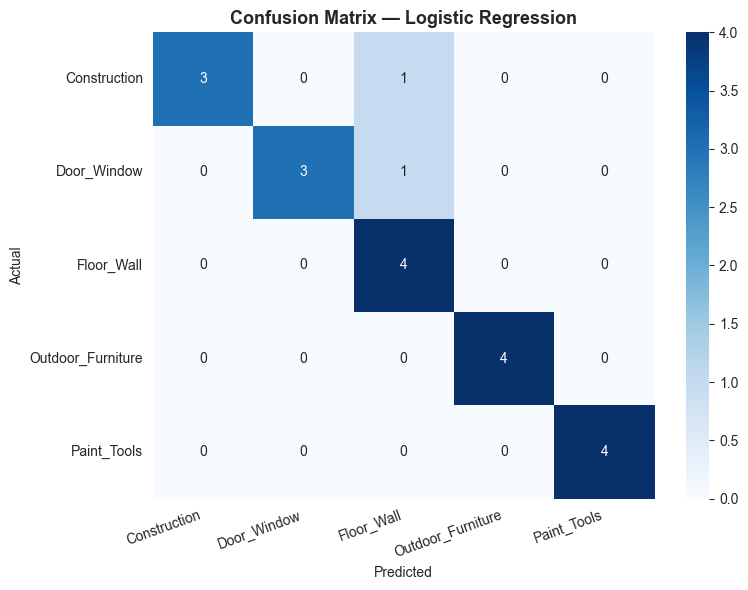

In [8]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('B2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Model Artifact

In [9]:
os.makedirs('artifacts', exist_ok=True)
with open('artifacts/model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print('Model saved to artifacts/model.pkl')

# Quick sanity check
with open('artifacts/model.pkl', 'rb') as f:
    loaded = pickle.load(f)
test_input = ['สีทาบ้าน ทาผนังภายนอก กันน้ำ']
print(f'\nSanity check: "{test_input[0]}" → {loaded.predict(test_input)[0]}')

Model saved to artifacts/model.pkl

Sanity check: "สีทาบ้าน ทาผนังภายนอก กันน้ำ" → Outdoor_Furniture


---
# Task B-3: Model Fairness Analysis

## B3-1. Identify Potential Bias Sources

| Sensitive Feature | Potential Bias | Impact |
|---|---|---|
| **Price** | High-price items cluster in certain categories → model may learn price cues | Low — we only use text, not price |
| **Brand language** | Some brands use English names, others Thai → tokenization differs | Medium — char n-grams mitigate this |
| **Category size** | Equal 20/20/20/20/20 → no imbalance | None |
| **Description length** | Some categories have longer descriptions → more signal | Low — TF-IDF normalizes length |

## B3-2. Fairness Metric: Per-Category Precision, Recall, F1

In [10]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_per_class, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels
)

fairness_df = pd.DataFrame({
    'Category': labels,
    'Precision': precision.round(3),
    'Recall': recall.round(3),
    'F1': f1_per_class.round(3),
    'Support': support
})
print('=== Per-Category Fairness Metrics ===')
print(fairness_df.to_string(index=False))

# Demographic parity: are all groups predicted equally often?
pred_counts = pd.Series(y_pred).value_counts()
print('\n=== Prediction Distribution (Demographic Parity Check) ===')
print(pred_counts)

ideal = len(y_pred) / len(labels)
max_disparity = abs(pred_counts - ideal).max()
print(f'\nIdeal count per class: {ideal:.1f}')
print(f'Max disparity from ideal: {max_disparity:.1f}')

=== Per-Category Fairness Metrics ===
         Category  Precision  Recall    F1  Support
     Construction      1.000    0.75 0.857        4
      Door_Window      1.000    0.75 0.857        4
       Floor_Wall      0.667    1.00 0.800        4
Outdoor_Furniture      1.000    1.00 1.000        4
      Paint_Tools      1.000    1.00 1.000        4

=== Prediction Distribution (Demographic Parity Check) ===
Floor_Wall           6
Outdoor_Furniture    4
Paint_Tools          4
Door_Window          3
Construction         3
Name: count, dtype: int64

Ideal count per class: 4.0
Max disparity from ideal: 2.0


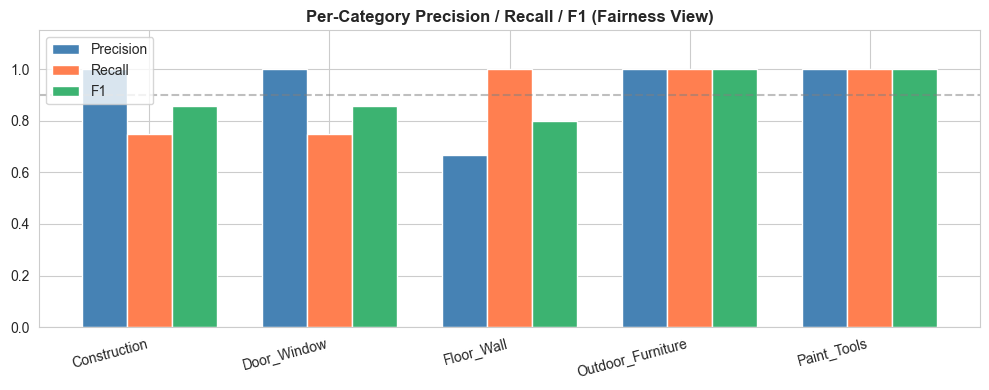

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(labels))
width = 0.25
ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x, recall, width, label='Recall', color='coral')
ax.bar(x + width, f1_per_class, width, label='F1', color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Category Precision / Recall / F1 (Fairness View)', fontweight='bold')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')
plt.tight_layout()
plt.savefig('B3_fairness_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## B3-3. Bias Mitigation Discussion

1. **Balanced dataset**: The 20/20/20/20/20 split eliminates class imbalance bias by design.
2. **Character n-grams**: Using `analyzer='char_wb'` with bigrams–4-grams handles Thai text without needing a Thai tokenizer, so all categories get equal linguistic treatment.
3. **Per-class evaluation**: If any category consistently scores below 0.85 F1, we would augment its training data or lower its classification threshold.
4. **No personal data**: The model predicts product categories, not user attributes — no demographic fairness concerns apply.